In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Loading dataset
dataset = pd.read_csv("train.csv")

In [ ]:
# Independent variables
X = dataset[['Loan Amount',
             'Debit to Income',
             'Employment Duration',
             'Home Ownership',
             'Total Current Balance',
             'Grade']]

# Dependent variable for regression
y = dataset['Interest Rate']

In [ ]:
# Handling missing values in numerical columns
numeric_columns = ['Loan Amount', 'Debit to Income', 'Home Ownership', 'Total Current Balance']

imputer = SimpleImputer(strategy='mean')

X[numeric_columns] = imputer.fit_transform(X[numeric_columns])

/tmp/ipykernel_17700/3863063265.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_columns] = imputer.fit_transform(X[numeric_columns])


In [ ]:
# Removing duplicate rows
dataset = dataset.drop_duplicates()

In [ ]:
# Encoding categorical variables
categorical_columns = ['Employment Duration', 'Grade']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_columns)],
    remainder='passthrough'
)

X = ct.fit_transform(X)

In [ ]:
# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Feature scaling
sc = StandardScaler(with_mean=False)

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# Reload dataset for regression outlier handling
dataset = pd.read_csv("train.csv")

# Select independent variables and target variable
feature_cols = [
    'Loan Amount',
    'Debit to Income',
    'Employment Duration',
    'Home Ownership',
    'Total Current Balance',
    'Grade'
]

target_col = 'Interest Rate'

# Keep selected columns only
data_reg = dataset[feature_cols + [target_col]].copy()

# Remove rows where target variable is missing
data_reg = data_reg.dropna(subset=[target_col]).copy()

# Separate X and y
X_reg = data_reg[feature_cols].copy()
y_reg = data_reg[target_col].copy()

# Numeric columns for outlier detection
numeric_outlier_cols = [
    'Loan Amount',
    'Debit to Income',
    'Home Ownership',
    'Total Current Balance'
]

# Handle missing values
imputer = SimpleImputer(strategy='mean')

X_reg.loc[:, numeric_outlier_cols] = imputer.fit_transform(
    X_reg[numeric_outlier_cols]
)

# Calculate IQR
Q1 = X_reg[numeric_outlier_cols].quantile(0.25)
Q3 = X_reg[numeric_outlier_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outlier_condition = (
    (X_reg[numeric_outlier_cols] < (Q1 - 1.5 * IQR)) |
    (X_reg[numeric_outlier_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

# Remove outliers
X_clean = X_reg.loc[~outlier_condition].copy()
y_clean = y_reg.loc[~outlier_condition].copy()

# Show dataset size
print("Original dataset size:", X_reg.shape)
print("Cleaned dataset size:", X_clean.shape)

Original dataset size: (67463, 6)
Cleaned dataset size: (61497, 6)


In [ ]:
# Encoding categorical variables
categorical_cols = [
    'Employment Duration',
    'Grade'
]

ct_reg = ColumnTransformer(
    transformers=[
        ('encoder',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

X_clean = ct_reg.fit_transform(X_clean)

# Feature scaling
sc_reg = StandardScaler(with_mean=False)

X_clean = sc_reg.fit_transform(X_clean)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_train)

poly_model = LinearRegression()

poly_model.fit(X_poly, y_train)

LinearRegression()

In [ ]:
ridge_model = Ridge()

ridge_model.fit(X_train, y_train)

Ridge()

In [ ]:
lasso_model = Lasso()

lasso_model.fit(X_train, y_train)

Lasso()

In [ ]:
elastic_model = ElasticNet()

elastic_model.fit(X_train, y_train)

ElasticNet()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_reg = DecisionTreeRegressor(
    random_state=42
)
decision_tree_reg.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
random_forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest_reg.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_linear = linear_model.predict(X_test)

In [ ]:
y_pred_poly = poly_model.predict(
    poly.transform(X_test)
)

In [ ]:
y_pred_ridge = ridge_model.predict(X_test)

In [ ]:
y_pred_lasso = lasso_model.predict(X_test)

In [ ]:
y_pred_elastic = elastic_model.predict(X_test)

In [ ]:
y_pred_tree = decision_tree_reg.predict(X_test)

In [ ]:
y_pred_rf = random_forest_reg.predict(X_test)

In [ ]:
# Multiple Linear Regression
mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

# Polynomial Regression
mse_poly = mean_squared_error(
    y_test,
    y_pred_poly
)

r2_poly = r2_score(
    y_test,
    y_pred_poly
)

# Ridge Regression
mse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

# Lasso Regression
mse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
)

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

# Elastic Net Regression
mse_elastic = mean_squared_error(
    y_test,
    y_pred_elastic
)

r2_elastic = r2_score(
    y_test,
    y_pred_elastic
)

# Decision Tree Regression
mse_tree = mean_squared_error(
    y_test,
    y_pred_tree
)

r2_tree = r2_score(
    y_test,
    y_pred_tree
)

# Random Forest Regression
mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

# Display Results
print("Linear Regression:", mse_linear, r2_linear)

print("Polynomial Regression:", mse_poly, r2_poly)

print("Ridge Regression:", mse_ridge, r2_ridge)

print("Lasso Regression:", mse_lasso, r2_lasso)

print("Elastic Net Regression:", mse_elastic, r2_elastic)

print("Decision Tree Regression:", mse_tree, r2_tree)

print("Random Forest Regression:", mse_rf, r2_rf)

Linear Regression: 14.094070149618172 -3.19778140642768e-05
Polynomial Regression: 14.096086414422103 -0.00017504005643043108
Ridge Regression: 14.09407004882675 -3.197066250026914e-05
Lasso Regression: 14.103541406172424 -0.0007040022416273661
Elastic Net Regression: 14.103541406172424 -0.0007040022416273661
Decision Tree Regression: 29.531582998450514 -1.0953867151513177
Random Forest Regression: 14.647228318312834 -0.039280814495830985


In [ ]:
print("Intercept:", ridge_model.intercept_)
print("Coefficients:", ridge_model.coef_)

Intercept: 11.896232708494878
Coefficients: [-0.02972235  0.0225615   0.01667165  0.02195186 -0.05129565  0.0039047
 -0.00342635  0.02238937  0.03008535  0.02140391 -0.01427841 -0.03684665
  0.04228834 -0.0202733 ]


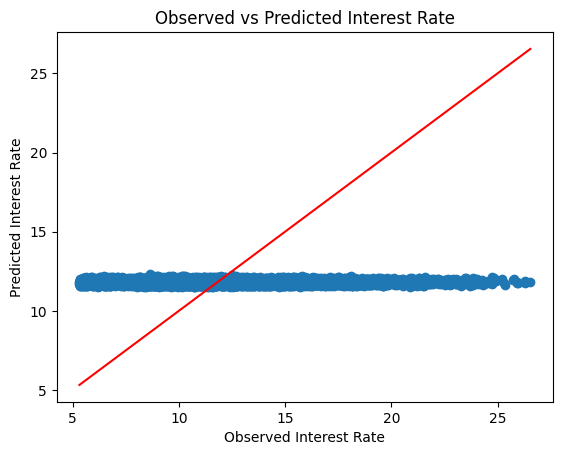

In [ ]:
  # Predict using the best model
  y_pred_best = ridge_model.predict(X_test)

  # Scatter plot
  plt.scatter(y_test, y_pred_best)

  # Perfect prediction line
  plt.plot(
      [y_test.min(), y_test.max()],
      [y_test.min(), y_test.max()],
      color='red'
  )

  plt.xlabel('Observed Interest Rate')
  plt.ylabel('Predicted Interest Rate')
  plt.title('Observed vs Predicted Interest Rate')

  plt.show()

In [ ]:
# Create dataframe of observed and predicted values
results = pd.DataFrame({
    'Observed Interest Rate': y_test.values,
    'Predicted Interest Rate': y_pred_best
})

# Select 5 random records
sample_results = results.sample(5, random_state=42)

print(sample_results)

       Observed Interest Rate  Predicted Interest Rate
3455                12.640530                11.904366
8063                11.178895                11.712019
11615               15.075322                11.939544
2677                11.235301                11.694453
6794                 9.260162                11.842776


In [ ]:
# Independent variables
X = dataset[['Loan Amount',
             'Debit to Income',
             'Employment Duration',
             'Home Ownership',
             'Total Current Balance',
             'Grade']]

# Target variable
y = dataset['Loan Status']

In [ ]:
# Remove rows where target variable is missing
data = pd.concat([X, y], axis=1)

data = data.dropna(subset=['Loan Status'])

X = data[['Loan Amount',
          'Debit to Income',
          'Employment Duration',
          'Home Ownership',
          'Total Current Balance',
          'Grade']]

y = data['Loan Status']

In [ ]:
# Encoding target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# Preprocessing setup
from sklearn.pipeline import Pipeline

numeric_features = [
    'Loan Amount',
    'Debit to Income',
    'Total Current Balance'
]

categorical_features = [
    'Employment Duration',
    'Grade',
    'Home Ownership'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model', KNeighborsClassifier())])

In [ ]:
from sklearn.svm import LinearSVC

svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVC(max_iter=5000))
])

svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model', LinearSVC(max_iter=5000))])

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

In [ ]:
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

random_forest_model.fit(X_train, y_train)

In [ ]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=30, max_depth=5, random_state=42))
])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model',
                 RandomForestClassifier(max_depth=5, n_estimators=30,
                                        random_state=42))])

In [ ]:
from sklearn.naive_bayes import BernoulliNB

naive_bayes_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', BernoulliNB())
])

naive_bayes_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model', BernoulliNB())])

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=200,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Loan Amount',
                                                   'Debit to Income',
                                                   'Total Current Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment Duration',
                                                   'Grade',
                                                   'Home Ownership'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), random_state=42))])

In [ ]:
# Predictions
y_pred_logistic = logistic_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test)

y_pred_svm = svm_model.predict(X_test)

y_pred_decision_tree = decision_tree_model.predict(X_test)

y_pred_random_forest = random_forest_model.predict(X_test)

y_pred_nb = naive_bayes_model.predict(X_test)

y_pred_mlp = mlp_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
# Logistic Regression
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

# KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)

# SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

# Decision Tree
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree, zero_division=0)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree, zero_division=0)
f1_decision_tree = f1_score(y_test, y_pred_decision_tree, zero_division=0)

# Random Forest
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
precision_random_forest = precision_score(y_test, y_pred_random_forest, zero_division=0)
recall_random_forest = recall_score(y_test, y_pred_random_forest, zero_division=0)
f1_random_forest = f1_score(y_test, y_pred_random_forest, zero_division=0)

# Naïve Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb,zero_division=0)

# Neural Network
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, zero_division=0)
recall_mlp = recall_score(y_test, y_pred_mlp, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, zero_division=0)

In [ ]:
print("Logistic Regression:",
      accuracy_logistic,
      precision_logistic,
      recall_logistic,
      f1_logistic)

print("KNN:",
      accuracy_knn,
      precision_knn,
      recall_knn,
      f1_knn)

print("SVM:",
      accuracy_svm,
      precision_svm,
      recall_svm,
      f1_svm)

print("Decision Tree:",
      accuracy_decision_tree,
      precision_decision_tree,
      recall_decision_tree,
      f1_decision_tree)

print("Random Forest:",
      accuracy_random_forest,
      precision_random_forest,
      recall_random_forest,
      f1_random_forest)

print("Naïve Bayes:",
      accuracy_nb,
      precision_nb,
      recall_nb,
      f1_nb)

print("Neural Network:",
      accuracy_mlp,
      precision_mlp,
      recall_mlp,
      f1_mlp)

Logistic Regression: 0.9097309716149115 0.0 0.0 0.0
KNN: 0.9044689839175869 0.09195402298850575 0.006568144499178982 0.012260536398467433
SVM: 0.9097309716149115 0.0 0.0 0.0
Decision Tree: 0.9096568591121322 0.0 0.0 0.0
Random Forest: 0.9097309716149115 0.0 0.0 0.0
Naïve Bayes: 0.9097309716149115 0.0 0.0 0.0
Neural Network: 0.9097309716149115 0.0 0.0 0.0


In [ ]:
# Predict using best classifier
y_pred_best = knn_model.predict(X_test)

# Count number of elements in each category
unique, counts = np.unique(y_pred_best, return_counts=True)

target_count = dict(zip(unique, counts))

print("Number of elements in each predicted category:")
print(target_count)

Number of elements in each predicted category:
{np.int64(0): np.int64(13406), np.int64(1): np.int64(87)}


In [ ]:
X_cluster = dataset[
    ['Loan Amount',
     'Total Current Balance']
]

In [ ]:
sc = StandardScaler()

X_cluster = sc.fit_transform(X_cluster)

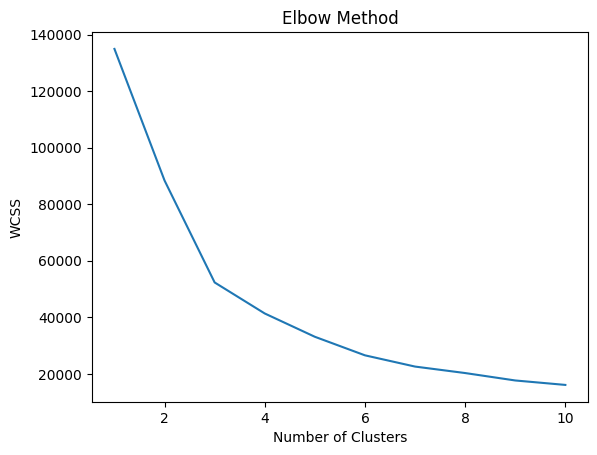

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(
    X_cluster
)

print(y_kmeans)

[2 0 1 ... 0 2 0]


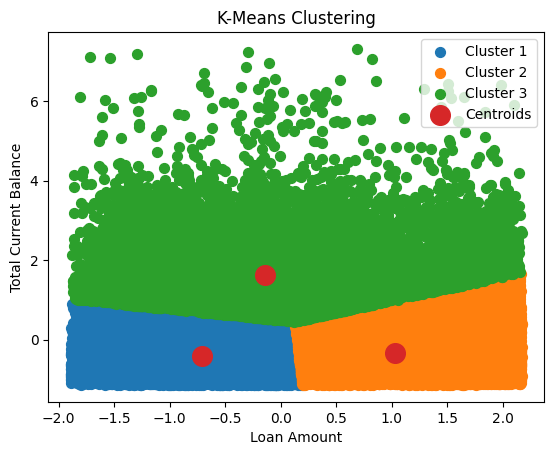

In [ ]:
plt.scatter(
    X_cluster[y_kmeans == 0, 0],
    X_cluster[y_kmeans == 0, 1],
    s=50,
    label='Cluster 1'
)
plt.scatter(
    X_cluster[y_kmeans == 1, 0],
    X_cluster[y_kmeans == 1, 1],
    s=50,
    label='Cluster 2'
)
plt.scatter(
    X_cluster[y_kmeans == 2, 0],
    X_cluster[y_kmeans == 2, 1],
    s=50,
    label='Cluster 3'
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    label='Centroids'
)
plt.xlabel('Loan Amount')

plt.ylabel(
    'Total Current Balance'
)

plt.title(
    'K-Means Clustering'
)
plt.legend()
plt.show()

In [ ]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(
    sch.linkage(
        X_cluster,
        method='ward'
    )
)

plt.title(
    'Dendrogram'
)

plt.xlabel(
    'Loan Applicants'
)

plt.ylabel(
    'Euclidean Distance'
)

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

y_hc = hc.fit_predict(
    X_cluster
)

print(y_hc)

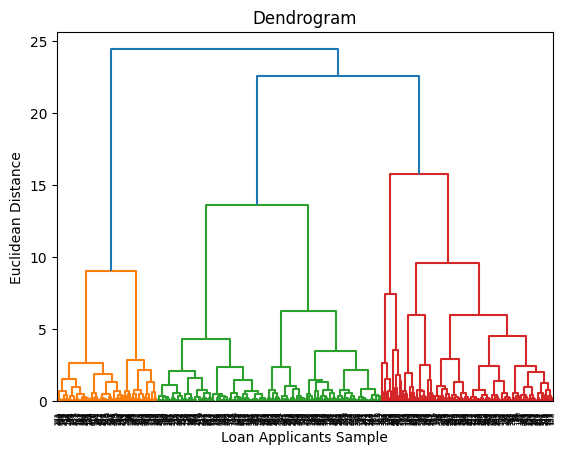

In [ ]:
# Take a sample for hierarchical clustering to avoid system crash
X_cluster_sample = X_cluster[:500]

import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(
    sch.linkage(X_cluster_sample, method='ward')
)

plt.title('Dendrogram')
plt.xlabel('Loan Applicants Sample')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

y_hc = hc.fit_predict(X_cluster_sample)

print(y_hc)

[0 2 1 2 2 1 1 0 2 2 2 2 1 1 1 1 1 2 2 0 2 2 2 0 2 2 2 2 0 2 0 1 2 0 0 0 2
 0 1 0 0 2 2 2 1 0 1 2 2 2 2 0 1 1 1 2 0 0 2 0 2 2 2 2 1 1 2 2 0 2 0 2 2 0
 0 0 2 0 0 0 1 0 2 2 0 2 2 2 1 2 2 0 0 1 2 0 1 2 0 2 0 2 0 0 1 2 2 0 0 2 0
 2 1 2 2 2 2 2 2 2 0 0 2 0 0 2 0 0 0 2 2 1 2 2 0 1 2 2 2 2 0 0 0 0 1 1 2 2
 1 1 0 1 0 0 0 2 0 1 0 0 2 2 1 1 2 2 2 2 2 0 2 0 2 2 0 1 0 2 1 1 2 0 1 2 0
 1 2 2 1 1 0 2 1 0 2 0 2 0 0 2 2 0 1 0 0 0 1 0 2 2 1 1 2 2 0 2 2 2 0 2 0 2
 0 0 0 1 0 2 0 2 0 0 0 2 0 0 0 0 2 1 2 2 0 0 1 2 2 0 0 2 0 2 2 1 2 2 0 2 2
 0 2 2 2 0 1 2 2 2 0 2 2 1 0 0 0 2 2 0 0 2 1 2 1 2 0 0 0 1 2 1 0 0 1 0 1 2
 2 0 2 1 2 2 0 1 0 2 2 0 2 2 1 1 2 1 0 2 0 1 1 2 1 1 2 2 0 1 0 0 0 2 2 1 2
 2 2 2 0 0 1 0 2 2 0 2 1 0 1 1 0 2 0 0 2 1 2 2 2 1 2 0 1 2 2 0 0 2 2 1 2 2
 2 0 1 2 0 2 2 2 0 2 0 2 2 0 0 0 0 2 0 0 1 0 0 2 2 1 1 2 0 1 2 0 2 0 0 2 1
 2 2 0 1 0 0 0 2 0 2 2 1 0 0 0 2 2 1 0 0 0 1 2 0 1 0 0 2 0 2 2 2 0 1 2 2 1
 2 2 1 0 0 2 0 2 2 2 2 0 2 1 1 0 0 2 1 2 2 2 0 2 0 0 1 2 1 1 0 0 2 2 0 1 2
 2 0 1 2 2 2 2 2 2 1 2 2 

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

y_dbscan = dbscan.fit_predict(X_cluster)

print(y_dbscan)

[0 0 0 ... 0 0 0]


In [ ]:
from sklearn.cluster import MiniBatchKMeans

mini_kmeans = MiniBatchKMeans(
    n_clusters=3,
    random_state=42
)

y_mini = mini_kmeans.fit_predict(X_cluster)

print(y_mini)

[2 0 1 ... 0 2 0]
